# Pipeline Completo de Treinamento — Do Protocolo à Produção

### Um guia de como treinar, avaliar, depurar e entregar modelos de ML

Este notebook implementa um **pipeline de treinamento** end-to-end,
com rastreabilidade completa via **Weights & Biases (W&B)**.

**Roteiro:**

| Fase | Conteúdo |
|------|----------|
| **0** | Setup, reprodutibilidade e versionamento de dados |
| **1** | Protocolo de experimentos (sem vazamento de dados) |
| **2** | Sanity checks — o modelo é capaz de aprender? |
| **3** | Baseline + configurações candidatas |
| **4** | Comparação com múltiplas seeds (significância estatística) |
| **5** | Ablation study — o que contribui de fato? |
| **6** | Learning Rate Finder & Scheduler tuning |
| **7** | Monitoramento profundo (gradientes, ativações, pesos) |
| **8** | Receita de depuração: "o modelo não aprende" |
| **9** | Seleção final com justificativa técnica |
| **10** | Export de artefatos e checklist de produção |

**Task:** Classificação de imagens com **Fashion-MNIST** (10 classes)
— rápido o suficiente para Colab, complexo o suficiente para demonstrar todos os conceitos.

> 💡 **Dica:** Use GPU no Colab (`Runtime > Change runtime type > T4 GPU`).

---
## Fase 0: Setup, Reprodutibilidade e Versionamento

### Por que reprodutibilidade importa?

Se você não consegue **reproduzir** um resultado, ele não existe cientificamente.
Em ML, aleatoriedade aparece em muitos lugares:
- Inicialização de pesos
- Ordem dos batches (shuffle)
- Dropout
- Augmentação de dados
- Operações CUDA não-determinísticas

Vamos controlar tudo isso.

In [ ]:
# Instalar dependências
!pip install wandb torchinfo -q

import os
import json
import time
import hashlib
import random
import math
import copy
from datetime import datetime
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchinfo import summary
import wandb

# Verificar hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128


In [ ]:
# === REPRODUTIBILIDADE ===
def set_seed(seed=42):
    """Fixa TODAS as fontes de aleatoriedade."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinismo total (pode reduzir performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
print('Seeds fixadas para reprodutibilidade total.')
print()

# === CONFIGURAÇÃO CENTRAL ===
# Toda config em UM lugar — nunca magic numbers espalhados pelo código
PROJECT_NAME = 'fashion-mnist-pipeline'

BASE_CONFIG = {
    # Dados
    'dataset': 'FashionMNIST',
    'val_fraction': 0.1,   # 10% do treino vira validação
    'num_workers': 2,
    # Treinamento
    'epochs': 15,
    'batch_size': 128,
    'optimizer': 'AdamW',
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'scheduler': 'cosine',
    # Modelo
    'model': 'SimpleCNN',
    'dropout': 0.25,
    'channels': [32, 64],
    'fc_dim': 128,
    'use_batchnorm': True,
    'activation': 'ReLU',
    # Reprodutibilidade
    'seed': 42,
}

print('Configuração base definida.')
for k, v in BASE_CONFIG.items():
    print(f'   {k}: {v}')

Seeds fixadas para reprodutibilidade total.

Configuração base definida.
   dataset: FashionMNIST
   val_fraction: 0.1
   num_workers: 2
   epochs: 15
   batch_size: 128
   optimizer: AdamW
   lr: 0.001
   weight_decay: 0.0001
   scheduler: cosine
   model: SimpleCNN
   dropout: 0.25
   channels: [32, 64]
   fc_dim: 128
   use_batchnorm: True
   activation: ReLU
   seed: 42


### Login no Weights & Biases

O W&B vai rastrear **tudo**: loss, métricas, gradientes, pesos, predições, artefatos.

Se não tiver conta, crie gratuitamente em [wandb.ai](https://wandb.ai).
Ou use `wandb.init(mode='offline')` para salvar localmente.

In [ ]:
# Login no W&B (cole sua API key quando solicitado)
# Alternativa: wandb.login(key='sua-key-aqui')
try:
    wandb.login()
    WANDB_MODE = 'online'
    print('W&B online — logs serão enviados para a nuvem.')
except:
    WANDB_MODE = 'offline'
    print('W&B offline — logs salvos localmente em ./wandb/')
    print('   Para ver online, crie conta em https://wandb.ai')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zanche (zanchettin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B online — logs serão enviados para a nuvem.


---
## Fase 1: Protocolo de Dados (Sem Vazamento!)

### O erro mais comum em ML: Data Leakage

**Data leakage** acontece quando informação do conjunto de teste "vaza" para o treino.
Isso infla métricas artificialmente e produz modelos que falham em produção.

### Fontes comuns de vazamento:

```
❌ Normalizar ANTES de dividir os dados
   (média/desvio calculados incluindo teste)

❌ Feature engineering com dados do teste
   (ex.: target encoding usando todo o dataset)

❌ Duplicatas entre train/val/test
   (mesmo paciente/documento/imagem em splits diferentes)

❌ Usar validação para tunar E para reportar resultado final
   (test set é sagrado — só toca UMA vez)
```

### Nosso protocolo:

```
Dataset Original (70k imagens)
    │
    ├── Train (54k) ──→ Treina o modelo
    │                    Estatísticas (média, std) calculadas AQUI
    │
    ├── Val (6k) ────→ Monitora overfitting, early stopping,
    │                    seleção de hiperparâmetros
    │
    └── Test (10k) ──→ Avaliação FINAL. Toca-se UMA VEZ.
                        Normalização usa stats do TRAIN.
```

In [ ]:
# === CARREGAR DADOS (SEM transforms por enquanto) ===
raw_train_full = datasets.FashionMNIST(root='./data', train=True, download=True)
raw_test = datasets.FashionMNIST(root='./data', train=False, download=True)

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train original:  {len(raw_train_full)} amostras')
print(f'Test (sagrado):  {len(raw_test)} amostras')
print(f'Classes:         {len(CLASS_NAMES)}')
print(f'Imagem shape:    {raw_train_full[0][0].size} (grayscale)')

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.4MB/s]

Train original:  60000 amostras
Test (sagrado):  10000 amostras
Classes:         10
Imagem shape:    (28, 28) (grayscale)


In [ ]:
# === VERSIONAMENTO DE DADOS ===
# Calcular hash do dataset para garantir que estamos sempre usando os mesmos dados
def dataset_hash(dataset, n_samples=1000):
    """Hash determinístico de um subset do dataset."""
    h = hashlib.sha256()
    indices = list(range(min(n_samples, len(dataset))))
    for i in indices:
        img, label = dataset[i]
        h.update(np.array(img).tobytes())
        h.update(str(label).encode())
    return h.hexdigest()[:16]

train_hash = dataset_hash(raw_train_full)
test_hash = dataset_hash(raw_test)
print(f'Hash train: {train_hash}')
print(f'Hash test:  {test_hash}')
print('(Se esses hashes mudarem, os dados mudaram — investigue!)')

Hash train: f126e22ca1e3ba9f
Hash test:  1d93b155284cdf31
(Se esses hashes mudarem, os dados mudaram — investigue!)


In [ ]:
# === SPLIT TRAIN/VAL (com estratificação por classe) ===
from torch.utils.data import Subset

def stratified_split(dataset, val_fraction, seed):
    """Split estratificado: mesma proporção de classes em train e val."""
    rng = np.random.RandomState(seed)
    targets = np.array([dataset[i][1] for i in range(len(dataset))])
    train_indices, val_indices = [], []

    for cls in np.unique(targets):
        cls_indices = np.where(targets == cls)[0]
        rng.shuffle(cls_indices)
        n_val = int(len(cls_indices) * val_fraction)
        val_indices.extend(cls_indices[:n_val])
        train_indices.extend(cls_indices[n_val:])

    return train_indices, val_indices

train_idx, val_idx = stratified_split(raw_train_full, BASE_CONFIG['val_fraction'], seed=42)
print(f'Split estratificado:')
print(f'  Train: {len(train_idx)} amostras')
print(f'  Val:   {len(val_idx)} amostras')

# Verificar: NÃO há sobreposição
assert len(set(train_idx) & set(val_idx)) == 0, '❌ VAZAMENTO: sobreposição train/val!'
print('  ✅ Zero sobreposição entre train e val')

# Verificar estratificação
train_labels = [raw_train_full[i][1] for i in train_idx]
val_labels = [raw_train_full[i][1] for i in val_idx]
print('\n  Distribuição por classe:')
for cls in range(10):
    t_pct = train_labels.count(cls) / len(train_labels) * 100
    v_pct = val_labels.count(cls) / len(val_labels) * 100
    print(f'    {CLASS_NAMES[cls]:12s}: train={t_pct:.1f}%  val={v_pct:.1f}%')

Split estratificado:
  Train: 54000 amostras
  Val:   6000 amostras
  ✅ Zero sobreposição entre train e val

  Distribuição por classe:
    T-shirt     : train=10.0%  val=10.0%
    Trouser     : train=10.0%  val=10.0%
    Pullover    : train=10.0%  val=10.0%
    Dress       : train=10.0%  val=10.0%
    Coat        : train=10.0%  val=10.0%
    Sandal      : train=10.0%  val=10.0%
    Shirt       : train=10.0%  val=10.0%
    Sneaker     : train=10.0%  val=10.0%
    Bag         : train=10.0%  val=10.0%
    Ankle boot  : train=10.0%  val=10.0%


In [ ]:
# === NORMALIZAÇÃO — calculada SOMENTE no train! ===
train_data = torch.stack([transforms.ToTensor()(raw_train_full[i][0]) for i in train_idx])
train_mean = train_data.mean().item()
train_std = train_data.std().item()
del train_data  # liberar memória

print(f'Estatísticas calculadas SOMENTE no train split:')
print(f'  mean = {train_mean:.4f}')
print(f'  std  = {train_std:.4f}')
print(f'  (Teste usa estas mesmas estatísticas — sem vazamento!)')

# === TRANSFORMS ===
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((train_mean,), (train_std,)),
])

# Aplicar transforms
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return self.transform(img), label

train_dataset = TransformedSubset(raw_train_full, train_idx, train_transform)
val_dataset = TransformedSubset(raw_train_full, val_idx, eval_transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=eval_transform)

print(f'\nDatasets prontos:')
print(f'  Train: {len(train_dataset)} (com augmentação)')
print(f'  Val:   {len(val_dataset)} (sem augmentação)')
print(f'  Test:  {len(test_dataset)} (sem augmentação, stats do train)')

Estatísticas calculadas SOMENTE no train split:
  mean = 0.2859
  std  = 0.3529
  (Teste usa estas mesmas estatísticas — sem vazamento!)

Datasets prontos:
  Train: 54000 (com augmentação)
  Val:   6000 (sem augmentação)
  Test:  10000 (sem augmentação, stats do train)


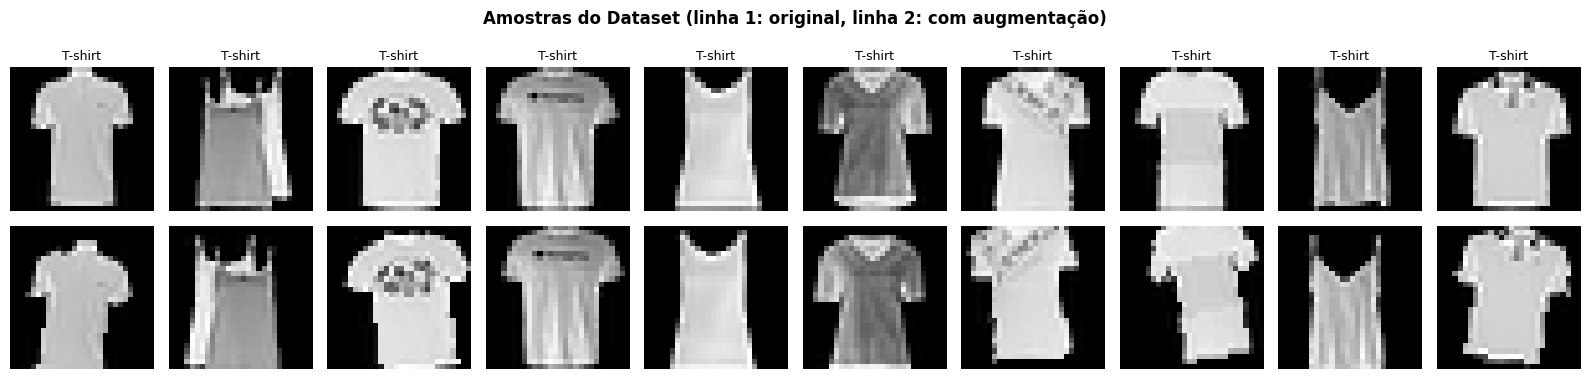

In [ ]:
# === VISUALIZAR DADOS ===
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Amostras do Dataset (linha 1: original, linha 2: com augmentação)', fontweight='bold')

for i in range(10):
    # Original
    img_orig, label = raw_train_full[train_idx[i]]
    axes[0, i].imshow(img_orig, cmap='gray')
    axes[0, i].set_title(CLASS_NAMES[label], fontsize=9)
    axes[0, i].axis('off')
    # Augmentado
    img_aug, _ = train_dataset[i]
    axes[1, i].imshow(img_aug.squeeze(), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## Fase 2: Sanity Checks — O Modelo É Capaz de Aprender?

### Antes de treinar de verdade, verifique:

1. **Loss inicial correta?** Para 10 classes com pesos aleatórios: $-\log(1/10) \approx 2.30$
2. **Overfit em 1 batch?** Se não consegue memorizar 1 batch, algo está errado
3. **Gradientes fluem?** Verificar que não são zero nem explodem
4. **Shapes corretas?** Input/output shapes batem com o esperado

Esses checks economizam **horas** de depuração.

In [ ]:
# === DEFINIR MODELOS ===

class SimpleCNN(nn.Module):
    """CNN simples — nosso baseline."""
    def __init__(self, channels=[32, 64], fc_dim=128, dropout=0.25,
                 use_batchnorm=True, activation='ReLU'):
        super().__init__()
        act_fn = nn.ReLU if activation == 'ReLU' else nn.GELU

        layers1 = [nn.Conv2d(1, channels[0], 3, padding=1)]
        if use_batchnorm: layers1.append(nn.BatchNorm2d(channels[0]))
        layers1 += [act_fn(), nn.MaxPool2d(2)]

        layers2 = [nn.Conv2d(channels[0], channels[1], 3, padding=1)]
        if use_batchnorm: layers2.append(nn.BatchNorm2d(channels[1]))
        layers2 += [act_fn(), nn.MaxPool2d(2)]

        self.features = nn.Sequential(*layers1, *layers2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[1] * 7 * 7, fc_dim),
            act_fn(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class DeeperCNN(nn.Module):
    """CNN mais profunda — candidata."""
    def __init__(self, channels=[32, 64, 128], fc_dim=256, dropout=0.3,
                 use_batchnorm=True, activation='GELU'):
        super().__init__()
        act_fn = nn.ReLU if activation == 'ReLU' else nn.GELU

        blocks = []
        in_ch = 1
        for ch in channels:
            block = [nn.Conv2d(in_ch, ch, 3, padding=1)]
            if use_batchnorm: block.append(nn.BatchNorm2d(ch))
            block += [act_fn(), nn.Conv2d(ch, ch, 3, padding=1)]
            if use_batchnorm: block.append(nn.BatchNorm2d(ch))
            block += [act_fn(), nn.MaxPool2d(2)]
            blocks.extend(block)
            in_ch = ch

        self.features = nn.Sequential(*blocks)
        # After 3 pools: 28 -> 14 -> 7 -> 3
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels[-1], fc_dim),
            act_fn(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(config):
    """Factory: cria modelo a partir da config."""
    if config['model'] == 'SimpleCNN':
        return SimpleCNN(
            channels=config.get('channels', [32, 64]),
            fc_dim=config.get('fc_dim', 128),
            dropout=config.get('dropout', 0.25),
            use_batchnorm=config.get('use_batchnorm', True),
            activation=config.get('activation', 'ReLU'),
        ).to(device)
    elif config['model'] == 'DeeperCNN':
        return DeeperCNN(
            channels=config.get('channels', [32, 64, 128]),
            fc_dim=config.get('fc_dim', 256),
            dropout=config.get('dropout', 0.3),
            use_batchnorm=config.get('use_batchnorm', True),
            activation=config.get('activation', 'GELU'),
        ).to(device)
    else:
        raise ValueError(f'Modelo desconhecido: {config["model"]}')

# Visualizar arquitetura
model_demo = build_model(BASE_CONFIG)
print(summary(model_demo, input_size=(1, 1, 28, 28), verbose=0))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-4                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-5                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-9                      [1, 3136]                 --
│    └─Linear: 2-10                      [1, 128]                  401,536
│   

In [ ]:
# === SANITY CHECK 1: Loss Inicial ===
model_check = build_model(BASE_CONFIG)
model_check.eval()

dummy_input = torch.randn(8, 1, 28, 28).to(device)
dummy_labels = torch.randint(0, 10, (8,)).to(device)

with torch.no_grad():
    logits = model_check(dummy_input)
    loss = F.cross_entropy(logits, dummy_labels)

expected_loss = -math.log(1/10)
print(f'Sanity Check 1 — Loss Inicial:')
print(f'  Loss calculada:  {loss.item():.4f}')
print(f'  Loss esperada:   {expected_loss:.4f} (= -log(1/10))')
print(f'  Diferença:       {abs(loss.item() - expected_loss):.4f}')
status = '✅ OK' if abs(loss.item() - expected_loss) < 0.5 else '❌ PROBLEMA'
print(f'  Status: {status}')

Sanity Check 1 — Loss Inicial:
  Loss calculada:  2.3260
  Loss esperada:   2.3026 (= -log(1/10))
  Diferença:       0.0234
  Status: ✅ OK


In [ ]:
# === SANITY CHECK 2: Overfit em 1 batch ===
print('Sanity Check 2 — Overfit em 1 batch:')
print('  (O modelo deve atingir ~100% accuracy em poucas iterações)\n')

loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
single_batch = next(iter(loader))
imgs, labels = single_batch[0].to(device), single_batch[1].to(device)

model_overfit = build_model(BASE_CONFIG)
optimizer_of = optim.Adam(model_overfit.parameters(), lr=1e-3)

for step in range(100):
    model_overfit.train()
    logits = model_overfit(imgs)
    loss = F.cross_entropy(logits, labels)
    optimizer_of.zero_grad()
    loss.backward()
    optimizer_of.step()

    acc = (logits.argmax(1) == labels).float().mean().item()
    if (step + 1) % 20 == 0 or step == 0:
        print(f'  Step {step+1:3d}: loss={loss.item():.4f}, acc={acc:.1%}')

final_acc = acc
status = '✅ OK' if final_acc > 0.95 else '❌ PROBLEMA — modelo não memoriza!'
print(f'\n  Accuracy final: {final_acc:.1%} → {status}')
del model_overfit, optimizer_of

Sanity Check 2 — Overfit em 1 batch:
  (O modelo deve atingir ~100% accuracy em poucas iterações)

  Step   1: loss=2.8173, acc=0.0%
  Step  20: loss=0.0000, acc=100.0%
  Step  40: loss=0.0000, acc=100.0%
  Step  60: loss=0.0000, acc=100.0%
  Step  80: loss=0.0000, acc=100.0%
  Step 100: loss=0.0000, acc=100.0%

  Accuracy final: 100.0% → ✅ OK


In [ ]:
# === SANITY CHECK 3: Gradientes ===
print('Sanity Check 3 — Fluxo de Gradientes:\n')

model_grad = build_model(BASE_CONFIG)
logits = model_grad(imgs)
loss = F.cross_entropy(logits, labels)
loss.backward()

print(f'  {"Camada":40s} | {"Grad Média":>12} | {"Grad Std":>12} | {"Zeros%":>8} | Status')
print(f'  {"-"*40}-+-{"-"*12}-+-{"-"*12}-+-{"-"*8}-+-------')

all_ok = True
for name, param in model_grad.named_parameters():
    if param.grad is not None:
        grad = param.grad
        g_mean = grad.abs().mean().item()
        g_std = grad.std().item()
        g_zeros = (grad == 0).float().mean().item() * 100

        status = '✅'
        if g_mean < 1e-7:
            status = '⚠️ vanishing'
            all_ok = False
        elif g_mean > 10:
            status = '⚠️ exploding'
            all_ok = False

        print(f'  {name:40s} | {g_mean:12.2e} | {g_std:12.2e} | {g_zeros:7.1f}% | {status}')

print(f'\n  Status geral: {"✅ Gradientes saudáveis" if all_ok else "⚠️ Verificar!"}')
del model_grad

Sanity Check 3 — Fluxo de Gradientes:

  Camada                                   |   Grad Média |     Grad Std |   Zeros% | Status
  -----------------------------------------+--------------+--------------+----------+-------
  features.0.weight                        |     2.25e-02 |     3.49e-02 |     0.0% | ✅
  features.0.bias                          |     1.08e-08 |     1.86e-08 |     0.0% | ⚠️ vanishing
  features.1.weight                        |     1.29e-02 |     1.63e-02 |     0.0% | ✅
  features.1.bias                          |     7.55e-03 |     9.57e-03 |     0.0% | ✅
  features.4.weight                        |     1.38e-02 |     1.84e-02 |     0.0% | ✅
  features.4.bias                          |     3.63e-09 |     5.01e-09 |    10.9% | ⚠️ vanishing
  features.5.weight                        |     1.56e-02 |     1.94e-02 |     0.0% | ✅
  features.5.bias                          |     1.44e-02 |     1.74e-02 |     0.0% | ✅
  classifier.1.weight                      |     

---
## Fase 3: Motor de Treinamento + Baseline

Vamos construir um **motor de treinamento reutilizável** que:
- Loga tudo no W&B
- Implementa early stopping
- Salva o melhor checkpoint
- Monitora gradientes e pesos
- Rastreia predições (confusion matrix)

In [ ]:
def create_dataloaders(config):
    """Cria dataloaders com a config."""
    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'],
        shuffle=True, num_workers=config['num_workers'],
        pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config['batch_size'] * 2,
        shuffle=False, num_workers=config['num_workers'], pin_memory=True
    )
    return train_loader, val_loader


def create_optimizer(model, config):
    """Cria optimizer + scheduler."""
    if config['optimizer'] == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'],
                                weight_decay=config['weight_decay'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'],
                              momentum=0.9, weight_decay=config['weight_decay'])
    else:
        raise ValueError(f'Optimizer: {config["optimizer"]}')

    scheduler = None
    if config.get('scheduler') == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epochs'])
    elif config.get('scheduler') == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    return optimizer, scheduler


@torch.no_grad()
def evaluate(model, loader):
    """Avalia modelo no loader. Retorna loss, accuracy, e predições."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        total_loss += F.cross_entropy(logits, labels, reduction='sum').item()
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {
        'loss': total_loss / total,
        'accuracy': correct / total,
        'preds': np.array(all_preds),
        'labels': np.array(all_labels),
    }

print('Funções auxiliares definidas.')

Funções auxiliares definidas.


In [ ]:
def train_experiment(config, run_name=None, tags=None, log_gradients=False,
                     patience=5, verbose=True):
    """
    Motor de treinamento completo com W&B logging.

    Args:
        config: dicionário de configuração
        run_name: nome do run no W&B
        tags: tags para organizar no W&B
        log_gradients: se True, loga histogramas de gradientes (mais lento)
        patience: epochs sem melhora para early stopping

    Returns:
        dict com resultados finais, melhor modelo, histórico
    """
    # Reprodutibilidade
    set_seed(config['seed'])

    # Inicializar W&B
    run = wandb.init(
        project=PROJECT_NAME,
        name=run_name,
        config=config,
        tags=tags or [],
        mode=WANDB_MODE,
        reinit=True,
    )

    # Construir tudo
    model = build_model(config)
    optimizer, scheduler = create_optimizer(model, config)
    train_loader, val_loader = create_dataloaders(config)

    # W&B: watch model (loga gradientes e pesos)
    if log_gradients:
        wandb.watch(model, log='all', log_freq=50)

    # Tracking
    best_val_loss = float('inf')
    best_val_acc = 0
    best_model_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    total_start = time.time()

    for epoch in range(config['epochs']):
        epoch_start = time.time()

        # === TRAIN ===
        model.train()
        train_loss_sum, train_correct, train_total = 0, 0, 0
        grad_norms = []

        for batch_idx, (imgs, labels) in enumerate(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            logits = model(imgs)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()

            # Monitorar norma dos gradientes
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float('inf'))
            grad_norms.append(total_norm.item())

            optimizer.step()

            train_loss_sum += loss.item() * labels.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

            # Log batch-level
            if batch_idx % 100 == 0:
                wandb.log({
                    'batch/train_loss': loss.item(),
                    'batch/grad_norm': total_norm.item(),
                })

        if scheduler:
            scheduler.step()

        # Métricas do epoch
        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total
        current_lr = optimizer.param_groups[0]['lr']

        # === VALIDAÇÃO ===
        val_metrics = evaluate(model, val_loader)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']

        # Gap de generalização
        gen_gap = train_acc - val_acc

        epoch_time = time.time() - epoch_start

        # Histórico
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # === LOG W&B (epoch level) ===
        log_dict = {
            'epoch': epoch,
            'train/loss': train_loss,
            'train/accuracy': train_acc,
            'val/loss': val_loss,
            'val/accuracy': val_acc,
            'generalization_gap': gen_gap,
            'lr': current_lr,
            'grad_norm/mean': np.mean(grad_norms),
            'grad_norm/max': np.max(grad_norms),
            'epoch_time_s': epoch_time,
        }

        # Log peso stats por camada
        for name, param in model.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                log_dict[f'weights/{name}_mean'] = param.data.mean().item()
                log_dict[f'weights/{name}_std'] = param.data.std().item()

        wandb.log(log_dict)

        # === EARLY STOPPING ===
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose:
            marker = ' ★' if epochs_no_improve == 0 else ''
            print(f'  Epoch {epoch+1:2d}/{config["epochs"]} | '
                  f'train: {train_loss:.4f} / {train_acc:.3f} | '
                  f'val: {val_loss:.4f} / {val_acc:.3f} | '
                  f'gap: {gen_gap:.3f} | '
                  f'lr: {current_lr:.2e} | '
                  f'{epoch_time:.1f}s{marker}')

        if epochs_no_improve >= patience:
            if verbose: print(f'  ⏹️  Early stopping (patience={patience})')
            break

    total_time = time.time() - total_start

    # Log confusion matrix na validação
    model.load_state_dict(best_model_state)
    val_final = evaluate(model, val_loader)
    wandb.log({
        'val/confusion_matrix': wandb.plot.confusion_matrix(
            probs=None, y_true=val_final['labels'].tolist(),
            preds=val_final['preds'].tolist(),
            class_names=CLASS_NAMES
        )
    })

    # Resumo final
    wandb.summary['best_val_loss'] = best_val_loss
    wandb.summary['best_val_accuracy'] = best_val_acc
    wandb.summary['total_time_s'] = total_time
    wandb.summary['stopped_epoch'] = epoch + 1

    wandb.finish()

    result = {
        'config': config,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'model_state': best_model_state,
        'history': history,
        'total_time': total_time,
        'stopped_epoch': epoch + 1,
    }
    return result

print('Motor de treinamento definido.')

Motor de treinamento definido.


### Treinar o Baseline

Primeira rodada: a configuração base. Tudo será comparado contra isso.

In [ ]:
print('=' * 60)
print('BASELINE: SimpleCNN + AdamW + Cosine LR')
print('=' * 60)

baseline_result = train_experiment(
    config=BASE_CONFIG,
    run_name='baseline_SimpleCNN',
    tags=['baseline', 'phase3'],
    log_gradients=True,
)

print(f'\nBaseline: val_acc = {baseline_result["best_val_acc"]:.4f}')

BASELINE: SimpleCNN + AdamW + Cosine LR


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  Epoch  1/15 | train: 0.6944 / 0.742 | val: 0.4455 / 0.829 | gap: -0.087 | lr: 9.89e-04 | 19.7s ★
  Epoch  2/15 | train: 0.5065 / 0.814 | val: 0.3734 / 0.856 | gap: -0.043 | lr: 9.57e-04 | 25.2s ★
  Epoch  3/15 | train: 0.4541 / 0.833 | val: 0.3251 / 0.882 | gap: -0.049 | lr: 9.05e-04 | 19.7s ★
  Epoch  4/15 | train: 0.4228 / 0.844 | val: 0.3336 / 0.874 | gap: -0.030 | lr: 8.35e-04 | 20.8s
  Epoch  5/15 | train: 0.4004 / 0.853 | val: 0.2987 / 0.887 | gap: -0.035 | lr: 7.50e-04 | 19.2s ★
  Epoch  6/15 | train: 0.3797 / 0.862 | val: 0.2905 / 0.893 | gap: -0.031 | lr: 6.55e-04 | 19.5s ★
  Epoch  7/15 | train: 0.3623 / 0.868 | val: 0.2738 / 0.900 | gap: -0.032 | lr: 5.52e-04 | 20.0s ★
  Epoch  8/15 | train: 0.3476 / 0.874 | val: 0.2905 / 0.893 | gap: -0.019 | lr: 4.48e-04 | 19.9s
  Epoch  9/15 | train: 0.3379 / 0.878 | val: 0.2612 / 0.906 | gap: -0.028 | lr: 3.45e-04 | 20.2s ★
  Epoch 10/15 | train: 0.3223 / 0.882 | val: 0.2586 / 0.905 | gap: -0.023 | lr: 2.50e-04 | 18.8s ★
  Epoch 11/15 

batch/grad_norm,▄▄▃▂▄▂▄▅▃▂▃▃▄▃▃▄▃▂▃▂▄▁▂▁▁▃▂▅▃█▁▂▃▂▂▂▅▅▃▂
batch/train_loss,█▂▂▃▂▂▂▂▂▂▂▁▂▁▂▂▂▁▂▂▁▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▂█▂▃▁▂▂▂▃▁▂▂▂▄▁
generalization_gap,▁▅▅▇▆▇▆█▇▇▇▇███
grad_norm/max,█▂▂▁▃▂▂▂▁▃▁▆▅▁▂
grad_norm/mean,█▃▄▃▃▃▂▂▁▂▁▁▁▁▁
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁
+10,...



Baseline: val_acc = 0.9135


---
## Fase 4: Configurações Candidatas

Vamos testar variações sistemáticas do baseline.
A regra: **mudar UMA coisa por vez** (ou ter um bom motivo para mudar várias).

### Candidatas:
1. **DeeperCNN** — modelo mais profundo (mais capacidade)
2. **SimpleCNN + GELU** — ativação diferente
3. **SimpleCNN + SGD** — optimizer diferente
4. **DeeperCNN + GELU + Dropout 0.4** — combinação avançada

In [ ]:
CANDIDATES = {
    'deeper_cnn': {
        **BASE_CONFIG,
        'model': 'DeeperCNN',
        'channels': [32, 64, 128],
        'fc_dim': 256,
        'dropout': 0.3,
    },
    'gelu_activation': {
        **BASE_CONFIG,
        'activation': 'GELU',
    },
    'sgd_optimizer': {
        **BASE_CONFIG,
        'optimizer': 'SGD',
        'lr': 0.05,
        'scheduler': 'step',
    },
    'deeper_gelu_highdrop': {
        **BASE_CONFIG,
        'model': 'DeeperCNN',
        'channels': [32, 64, 128],
        'fc_dim': 256,
        'activation': 'GELU',
        'dropout': 0.4,
    },
}

candidate_results = {}

for name, config in CANDIDATES.items():
    print(f'\n{"=" * 60}')
    print(f'🔬 Candidata: {name}')
    print(f'{"=" * 60}')
    result = train_experiment(
        config=config,
        run_name=f'candidate_{name}',
        tags=['candidate', 'phase4'],
    )
    candidate_results[name] = result
    print(f'  → val_acc = {result["best_val_acc"]:.4f}')

print(f'\n{"=" * 60}')
print('RESUMO DAS CANDIDATAS:')
print(f'{"Config":>25} | {"Val Acc":>8} | {"Val Loss":>9} | {"Δ vs Baseline":>14}')
print('-' * 65)
print(f'{"baseline":>25} | {baseline_result["best_val_acc"]:>8.4f} | {baseline_result["best_val_loss"]:>9.4f} | {"—":>14}')
for name, res in candidate_results.items():
    delta = res['best_val_acc'] - baseline_result['best_val_acc']
    sign = '+' if delta >= 0 else ''
    print(f'{name:>25} | {res["best_val_acc"]:>8.4f} | {res["best_val_loss"]:>9.4f} | {sign}{delta:>13.4f}')


🔬 Candidata: deeper_cnn


  Epoch  1/15 | train: 0.5936 / 0.782 | val: 0.4231 / 0.843 | gap: -0.060 | lr: 9.89e-04 | 42.3s ★
  Epoch  2/15 | train: 0.3830 / 0.859 | val: 0.3573 / 0.868 | gap: -0.009 | lr: 9.57e-04 | 33.0s ★
  Epoch  3/15 | train: 0.3324 / 0.878 | val: 0.3671 / 0.866 | gap: 0.012 | lr: 9.05e-04 | 30.7s
  Epoch  4/15 | train: 0.3015 / 0.889 | val: 0.2709 / 0.900 | gap: -0.011 | lr: 8.35e-04 | 37.9s ★
  Epoch  5/15 | train: 0.2812 / 0.898 | val: 0.2481 / 0.908 | gap: -0.009 | lr: 7.50e-04 | 22.3s ★
  Epoch  6/15 | train: 0.2617 / 0.905 | val: 0.2587 / 0.908 | gap: -0.003 | lr: 6.55e-04 | 21.9s
  Epoch  7/15 | train: 0.2491 / 0.909 | val: 0.2106 / 0.923 | gap: -0.014 | lr: 5.52e-04 | 21.3s ★
  Epoch  8/15 | train: 0.2322 / 0.917 | val: 0.2223 / 0.923 | gap: -0.006 | lr: 4.48e-04 | 20.6s
  Epoch  9/15 | train: 0.2213 / 0.919 | val: 0.2239 / 0.921 | gap: -0.002 | lr: 3.45e-04 | 21.2s
  Epoch 10/15 | train: 0.2077 / 0.924 | val: 0.2019 / 0.928 | gap: -0.004 | lr: 2.50e-04 | 21.1s ★
  Epoch 11/15 | tra

batch/grad_norm,▄▅▅▄▆▄█▃▄▄▃▃▃▃▃▂▂▃▂▂▃▁▃▄▁▄▃▂▂▁▃▃▅▁▄▂▂▄▄▃
batch/train_loss,█▇▆▆▃▃▄▄▂▅▂▃▃▃▄▃▃▄▃▂▃▃▄▁▂▂▃▃▁▂▃▁▄▂▂▁▃▂▂▂
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,█▅▄▇▂▂▁▁▁▁▂▁▁▁▁
generalization_gap,▁▆█▆▆▇▆▆▇▆▆▇▇▇▇
grad_norm/max,▆█▆▃▃▂▁▂▂▁▁▂▂▁▃
grad_norm/mean,█▆▄▃▂▁▁▁▁▁▁▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▄▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


  → val_acc = 0.9343

🔬 Candidata: gelu_activation


  Epoch  1/15 | train: 0.6534 / 0.756 | val: 0.4411 / 0.832 | gap: -0.075 | lr: 9.89e-04 | 21.2s ★
  Epoch  2/15 | train: 0.4786 / 0.823 | val: 0.3647 / 0.859 | gap: -0.035 | lr: 9.57e-04 | 18.8s ★
  Epoch  3/15 | train: 0.4269 / 0.844 | val: 0.3044 / 0.888 | gap: -0.044 | lr: 9.05e-04 | 18.8s ★
  Epoch  4/15 | train: 0.3975 / 0.855 | val: 0.3029 / 0.887 | gap: -0.032 | lr: 8.35e-04 | 20.3s ★
  Epoch  5/15 | train: 0.3755 / 0.862 | val: 0.3057 / 0.886 | gap: -0.024 | lr: 7.50e-04 | 18.9s
  Epoch  6/15 | train: 0.3569 / 0.870 | val: 0.2820 / 0.894 | gap: -0.024 | lr: 6.55e-04 | 19.1s ★
  Epoch  7/15 | train: 0.3431 / 0.874 | val: 0.2643 / 0.903 | gap: -0.029 | lr: 5.52e-04 | 19.7s ★
  Epoch  8/15 | train: 0.3259 / 0.880 | val: 0.2740 / 0.901 | gap: -0.021 | lr: 4.48e-04 | 18.9s
  Epoch  9/15 | train: 0.3157 / 0.884 | val: 0.2512 / 0.911 | gap: -0.026 | lr: 3.45e-04 | 20.1s ★
  Epoch 10/15 | train: 0.3040 / 0.888 | val: 0.2466 / 0.909 | gap: -0.021 | lr: 2.50e-04 | 19.1s ★
  Epoch 11/15 

...

batch/grad_norm,█▄▂▃▂▂▂▂▂▁▂▂▁▁▁▂▂▂▁▁▂▂▁▃▂▂▂▂▁▃▁▁▂▂▁▂▂▂▂▂
batch/train_loss,█▆▆▅▄▅▃▄▃▃▃▁▃▃▃▆▃▂▄▂▃▂▁▃▁▃▃▃▃▁▄▁▂▁▂▃▂▂▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▅▂█▂▂▆▁▂▄▂▅▂▂▆▁
generalization_gap,▁▅▅▇▆▇▇▇▇██▇███
grad_norm/max,█▂▁▁▁▁▁▁▂▁▁▁▂▁▁
grad_norm/mean,█▂▂▁▁▁▁▁▁▁▁▁▂▂▂
lr,████▄▄▄▄▄▂▂▂▂▂▁
train/accuracy,▁▅▆▆▇▇▇████████
train/loss,█▄▃▃▃▂▂▂▂▁▁▁▁▁▁
+10,...


  → val_acc = 0.9113

🔬 Candidata: deeper_gelu_highdrop


  Epoch  1/15 | train: 0.5800 / 0.786 | val: 0.3614 / 0.869 | gap: -0.083 | lr: 9.89e-04 | 19.7s ★
  Epoch  2/15 | train: 0.3749 / 0.862 | val: 0.3666 / 0.869 | gap: -0.007 | lr: 9.57e-04 | 20.6s
  Epoch  3/15 | train: 0.3220 / 0.883 | val: 0.2903 / 0.896 | gap: -0.014 | lr: 9.05e-04 | 19.6s ★
  Epoch  4/15 | train: 0.2956 / 0.891 | val: 0.2724 / 0.902 | gap: -0.011 | lr: 8.35e-04 | 19.9s ★
  Epoch  5/15 | train: 0.2745 / 0.901 | val: 0.2363 / 0.910 | gap: -0.009 | lr: 7.50e-04 | 21.2s ★
  Epoch  6/15 | train: 0.2537 / 0.907 | val: 0.2491 / 0.910 | gap: -0.003 | lr: 6.55e-04 | 19.6s
  Epoch  7/15 | train: 0.2445 / 0.911 | val: 0.2150 / 0.921 | gap: -0.010 | lr: 5.52e-04 | 21.2s ★
  Epoch  8/15 | train: 0.2275 / 0.917 | val: 0.2152 / 0.922 | gap: -0.005 | lr: 4.48e-04 | 19.9s
  Epoch  9/15 | train: 0.2160 / 0.921 | val: 0.2067 / 0.925 | gap: -0.004 | lr: 3.45e-04 | 21.2s ★
  Epoch 10/15 | train: 0.2024 / 0.927 | val: 0.1970 / 0.928 | gap: -0.001 | lr: 2.50e-04 | 19.9s ★
  Epoch 11/15 | 

batch/grad_norm,▅▄▇▆▄▄▅█▃▄▄▅▂▃▄▃▂▂▂▁▃▅▂▁▃▃▁▁▄▄▆▅▆▆▃▄▄▄▂▃
batch/train_loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▂▅▁▂█▁█▂█▂▆▄▂▆▁
generalization_gap,▁▇▇▇▇█▇▇██▇████
grad_norm/max,▆█▃▂▁▂▂▃▂▃▁▆▅▃▄
grad_norm/mean,█▅▄▂▁▁▁▁▁▁▁▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▄▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


  → val_acc = 0.9382

📊 RESUMO DAS CANDIDATAS:
                   Config |  Val Acc |  Val Loss |  Δ vs Baseline
-----------------------------------------------------------------
                 baseline |   0.9135 |    0.2398 |              —
               deeper_cnn |   0.9343 |    0.1806 | +       0.0208
          gelu_activation |   0.9165 |    0.2297 | +       0.0030
            sgd_optimizer |   0.9113 |    0.2439 |       -0.0022
     deeper_gelu_highdrop |   0.9382 |    0.1744 | +       0.0247


---
## Fase 5: Comparação com Múltiplas Seeds

### Por que múltiplas seeds?

Um único run pode dar resultados enganosos. A diferença entre duas configs pode ser
apenas **sorte** (a seed favoreceu uma). Precisamos de **significância estatística**.

Vamos pegar as **2 melhores candidatas** (+ baseline) e rodar cada uma com 5 seeds.

In [ ]:
# Selecionar top 2 candidatas + baseline
all_results = {'baseline': baseline_result}
all_results.update(candidate_results)

sorted_configs = sorted(all_results.items(), key=lambda x: -x[1]['best_val_acc'])
top_names = [name for name, _ in sorted_configs[:3]]  # top 3

print(f'Top 3 configurações para multi-seed: {top_names}')

SEEDS = [42, 123, 456, 789, 1337]
multi_seed_results = defaultdict(list)

for config_name in top_names:
    for seed in SEEDS:
        if config_name == 'baseline':
            config = {**BASE_CONFIG, 'seed': seed}
        else:
            config = {**CANDIDATES[config_name], 'seed': seed}

        print(f'\n  🌱 {config_name} | seed={seed}', end=' ')

        result = train_experiment(
            config=config,
            run_name=f'multiseed_{config_name}_s{seed}',
            tags=['multi-seed', 'phase5', config_name],
            verbose=False,
        )
        multi_seed_results[config_name].append(result['best_val_acc'])
        print(f'→ val_acc={result["best_val_acc"]:.4f}')

# Resumo estatístico
print(f'\n{"=" * 60}')
print('RESULTADOS MULTI-SEED:')
print(f'{"Config":>25} | {"Mean":>7} | {"Std":>7} | {"Min":>7} | {"Max":>7} | Seeds')
print('-' * 80)
for name in top_names:
    accs = multi_seed_results[name]
    vals = '  '.join([f'{a:.4f}' for a in accs])
    print(f'{name:>25} | {np.mean(accs):>7.4f} | {np.std(accs):>7.4f} | '
          f'{np.min(accs):>7.4f} | {np.max(accs):>7.4f} | {vals}')

Top 3 configurações para multi-seed: ['deeper_gelu_highdrop', 'deeper_cnn', 'gelu_activation']

  🌱 deeper_gelu_highdrop | seed=42 

batch/grad_norm,▅▇█▅▄▅▂▂▃▃▂▄▅▃▃▄▂▂▂▂▅▄▃▃▃▃▂▂▅▅▅▁▆▆▄▅▂▇▅▃
batch/train_loss,█▆▆▄▅▄▅▅▅▃▃▃▃▄▃▃▃▃▃▁▁▃▂▂▂▄▂▂▂▂▃▄▁▄▂▂▁▁▂▃
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▃█▂▂▂▁▂▁▂▁▂▁▂▁▁
generalization_gap,▁▇▇▇▇█▇▇██▇████
grad_norm/max,▆█▃▂▁▂▂▃▂▃▁▆▅▃▄
grad_norm/mean,█▅▄▂▁▁▁▁▁▁▁▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▄▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


→ val_acc=0.9382

  🌱 deeper_gelu_highdrop | seed=123 

batch/grad_norm,▆▅▇█▇▆▃▃▃▃▆▄▄▄▃▃▂▃▂▄▃▃▁▂▄▃▂▄▄▃▃▄▇▂▇▄▂▄▄▄
batch/train_loss,█▂▂▂▂▂▂▁▂▂▂▁▁▁▂▁▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▁▆▂▇▁█▂▆▂▅▄▃▇▂█
generalization_gap,▁▅▆█▆▆▇▇▇▇▇▇▇██
grad_norm/max,██▄▃▃▂▁▁▂▄▂▅▄▄▄
grad_norm/mean,█▆▃▂▂▂▁▁▁▁▂▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


→ val_acc=0.9338

  🌱 deeper_gelu_highdrop | seed=456 

...

→ val_acc=0.9145

  🌱 gelu_activation | seed=789 

batch/grad_norm,▇▄▄▄▅▂▃▃▅▂▂▄▂▄▄▂▃██▇▆▃▃▃█▆▃▂▄▂▁▄▄▅▃▃▅▂▄▂
batch/train_loss,█▃▂▃▂▁▂▂▁▂▁▂▂▂▁▂▁▂▁▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,█▂▁▆▁▅▄▁▁▇▁▄▆▂▆
generalization_gap,▁▆▇▇▇▇▇▇▇▇█████
grad_norm/max,▆▄▄▁▃▄▃▃▅▃█▇▃▃▃
grad_norm/mean,█▅▄▄▃▄▂▂▃▂▂▂▁▂▁
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▆▇▇▇██████
train/loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁
+10,...


→ val_acc=0.9122

  🌱 gelu_activation | seed=1337 

batch/grad_norm,▆▄▃▅▄▂▅▃▄█▃▄▇▂▄▄▂▃▄▂▃█▃▂▄▂▃▄▂▂▆█▂▂▂▂▂▄▂▁
batch/train_loss,█▃▂▂▂▂▂▁▁▂▁▂▂▂▂▂▂▁▁▁▁▁▂▁▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,█▂▁▆▁▁▅▁▁▄▃▂▃▇▃
generalization_gap,▁▄▇▇▇▇▆▇█▇▇▇███
grad_norm/max,█▄▁▁▂▂▃▄▂▂▄▆▃▂▆
grad_norm/mean,█▅▄▄▃▃▃▃▃▂▂▂▂▂▁
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▆▇▇▇▇█████
train/loss,█▅▄▃▃▃▂▂▂▂▁▁▁▁▁
+10,...


→ val_acc=0.9133

RESULTADOS MULTI-SEED:
                   Config |    Mean |     Std |     Min |     Max | Seeds
--------------------------------------------------------------------------------
     deeper_gelu_highdrop |  0.9344 |  0.0019 |  0.9327 |  0.9382 | 0.9382  0.9338  0.9337  0.9335  0.9327
               deeper_cnn |  0.9344 |  0.0011 |  0.9330 |  0.9365 | 0.9343  0.9340  0.9330  0.9343  0.9365
          gelu_activation |  0.9147 |  0.0018 |  0.9122 |  0.9170 | 0.9165  0.9170  0.9145  0.9122  0.9133



Testes de Significância (Welch t-test, α=0.05):

  deeper_gelu_highdrop vs deeper_cnn:
    Δ média = -0.0001, t = -0.059, p = 0.9546 → ❌ Não significativo

  deeper_gelu_highdrop vs gelu_activation:
    Δ média = +0.0197, t = 14.718, p = 0.0000 → ✅ Significativo



/tmp/ipykernel_2652/356742057.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_bp, labels=top_names, patch_artist=True)


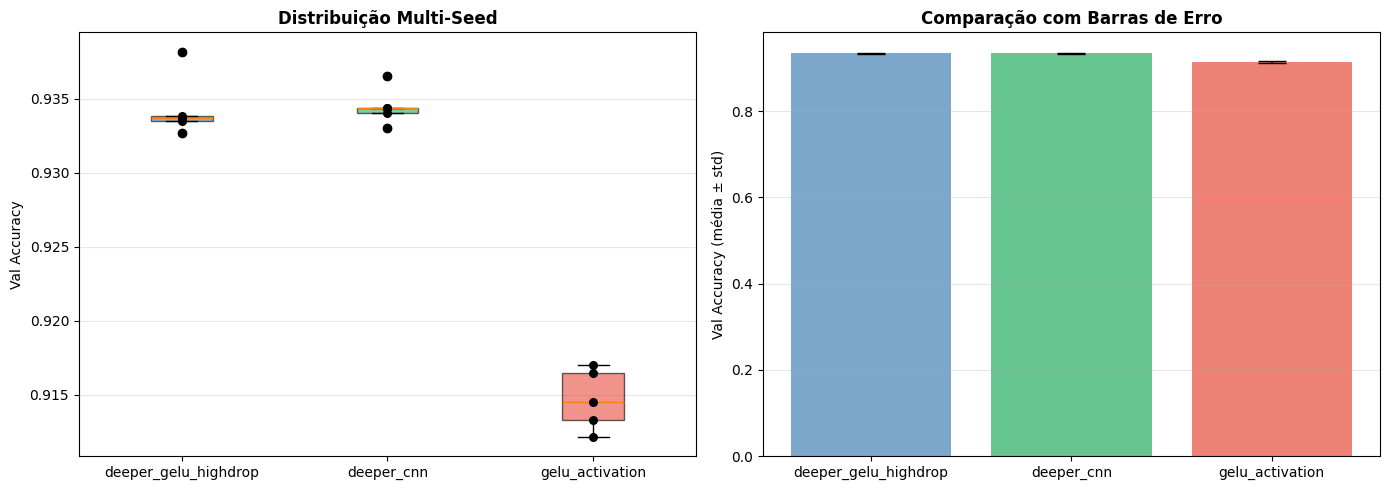

In [ ]:
# === TESTE DE SIGNIFICÂNCIA ESTATÍSTICA ===
from scipy import stats

print('\nTestes de Significância (Welch t-test, α=0.05):\n')

baseline_accs = multi_seed_results[top_names[0]]

for name in top_names[1:]:
    other_accs = multi_seed_results[name]
    t_stat, p_value = stats.ttest_ind(baseline_accs, other_accs, equal_var=False)
    diff = np.mean(baseline_accs) - np.mean(other_accs)
    sig = '✅ Significativo' if p_value < 0.05 else '❌ Não significativo'
    print(f'  {top_names[0]} vs {name}:')
    print(f'    Δ média = {diff:+.4f}, t = {t_stat:.3f}, p = {p_value:.4f} → {sig}')
    print()

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
data_bp = [multi_seed_results[n] for n in top_names]
bp = ax1.boxplot(data_bp, labels=top_names, patch_artist=True)
colors = ['steelblue', '#27ae60', '#e74c3c']
for patch, color in zip(bp['boxes'], colors[:len(top_names)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
# Scatter individual seeds
for i, name in enumerate(top_names):
    ax1.scatter([i+1]*len(multi_seed_results[name]), multi_seed_results[name],
                color='black', s=30, zorder=5)
ax1.set_ylabel('Val Accuracy')
ax1.set_title('Distribuição Multi-Seed', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Bar com error bars
means = [np.mean(multi_seed_results[n]) for n in top_names]
stds = [np.std(multi_seed_results[n]) for n in top_names]
bars = ax2.bar(top_names, means, yerr=stds, capsize=10, color=colors[:len(top_names)], alpha=0.7)
ax2.set_ylabel('Val Accuracy (média ± std)')
ax2.set_title('Comparação com Barras de Erro', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Fase 6: Ablation Study — O Que Contribui de Fato?

### O que é ablation?

"Ablação" vem da medicina — remover partes para entender a contribuição de cada uma.
Em ML: pegamos a **melhor configuração** e removemos/desligamos componentes
um a um para medir quanto cada um contribui.

```
Config completa:      A + B + C + D → 92%
Sem batchnorm (-C):   A + B + D     → 89%  (C contribui +3%)
Sem dropout (-D):     A + B + C     → 90%  (D contribui +2%)
Sem augmentação (-A): B + C + D     → 91%  (A contribui +1%)
```

In [ ]:
# Usar a melhor config como base para ablação
best_config_name = top_names[0]
if best_config_name == 'baseline':
    best_config = BASE_CONFIG.copy()
else:
    best_config = CANDIDATES[best_config_name].copy()

print(f'Base para ablação: {best_config_name}')
print(f'Val acc referência: {np.mean(multi_seed_results[best_config_name]):.4f}\n')

# Definir ablações
ABLATIONS = {
    'full (referência)': {},  # nenhuma mudança
    '- batchnorm': {'use_batchnorm': False},
    '- dropout (=0)': {'dropout': 0.0},
    '- scheduler': {'scheduler': None},
    '- augmentação': {},  # tratado especialmente
    '- weight_decay': {'weight_decay': 0.0},
    'lr 10x maior': {'lr': best_config['lr'] * 10},
    'lr 10x menor': {'lr': best_config['lr'] / 10},
}

ablation_results = {}

# Salvar transform original e criar versão sem augmentação
original_train_transform = train_dataset.transform

for abl_name, overrides in ABLATIONS.items():
    abl_config = {**best_config, **overrides, 'seed': 42}

    # Caso especial: sem augmentação
    if abl_name == '- augmentação':
        train_dataset.transform = eval_transform
    else:
        train_dataset.transform = original_train_transform

    print(f'  Ablação: {abl_name}', end=' ')
    result = train_experiment(
        config=abl_config,
        run_name=f'ablation_{abl_name}',
        tags=['ablation', 'phase6'],
        verbose=False,
    )
    ablation_results[abl_name] = result['best_val_acc']
    print(f'→ val_acc={result["best_val_acc"]:.4f}')

# Restaurar transform
train_dataset.transform = original_train_transform

# Tabela de resultados
ref_acc = ablation_results['full (referência)']
print(f'\n{"=" * 60}')
print('RESULTADO DA ABLAÇÃO:')
print(f'{"Configuração":>25} | {"Val Acc":>8} | {"Δ":>8} | Impacto')
print('-' * 65)
for name, acc in sorted(ablation_results.items(), key=lambda x: -x[1]):
    delta = acc - ref_acc
    if name == 'full (referência)':
        impact = '(base)'
    elif delta < -0.01:
        impact = '🔴 IMPORTANTE'
    elif delta < -0.005:
        impact = '🟡 moderado'
    else:
        impact = '🟢 dispensável'
    print(f'{name:>25} | {acc:>8.4f} | {delta:>+8.4f} | {impact}')

Base para ablação: deeper_gelu_highdrop
Val acc referência: 0.9344

  Ablação: full (referência) 

batch/grad_norm,▄▇▆▃█▄▅█▆▃▄▄▄▂▃▄▁▄▂▁▂▁▁▃▃▃▂▃▃▂▄▄▄▆▆▄▁▆▄▃
batch/train_loss,▇█▇▅▃▃▃▃▄▂▅▃▃▃▃▄▃▃▂▃▃▃▂▂▂▃▄▃▂▃▁▃▂▂▁▂▁▂▂▃
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,█▅▅▆▂▅▂▄▂▄▁▄▁▃▂
generalization_gap,▁▇▇▇▇█▇▇██▇████
grad_norm/max,▆█▃▂▁▂▂▃▂▃▁▆▅▃▄
grad_norm/mean,█▅▄▂▁▁▁▁▁▁▁▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▄▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


→ val_acc=0.9382
  Ablação: - batchnorm 

batch/grad_norm,▅█▅▃▃▂▆▃▃▃▃▂▄▂▃▂▁▅▄▂▃▁▃▃▃▁▂▃▁▁▄▃▃▂▃▃▃▂▁▃
batch/train_loss,█▆▇▆▄▃▄▄▄▄▄▅▃▃▄▂▂▃▃▃▃▁▂▁▂▂▂▂▃▃▂▃▁▃▂▂▂▂▁▃
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▂▄▅▂▇▂█▂▅▄▂▇▁▇▂
generalization_gap,▁▆▆▇▇██████████
grad_norm/max,█▂▄▃▄▂▁▁▂▁▁▂▁▁▃
grad_norm/mean,█▄▄▃▃▂▂▂▁▁▁▁▁▁▁
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▅▆▆▇▇▇▇███████
train/loss,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁
+18,...


→ val_acc=0.9240
  Ablação: - dropout (=0) 

...

→ val_acc=0.9392
  Ablação: lr 10x maior 

batch/grad_norm,█▃▃▃▂▂▂▂▂▂▁▂▃▁▂▂▂▁▂▂▁▁▂▁▂▁▂▂▂▁▂▂▁▂▃▂▂▂▂▁
batch/train_loss,█▃▂▂▂▂▂▂▁▂▁▂▂▂▂▁▁▂▁▁▁▁▁▁▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▄▃▇▂█▁▇▁█▄▅▆▅▇▂
generalization_gap,▁▅▆▆▇█▆▇▇▆▇▇▇▇▇
grad_norm/max,█▂▂▂▂▂▁▁▁▁▁▁▁▁▁
grad_norm/mean,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▅▅▆▆▇▇▇▇▇█████
train/loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


→ val_acc=0.9365
  Ablação: lr 10x menor 

batch/grad_norm,▁▃▃▃▃▅▄▄█▃▄▄▃▆▄▅▇▆▆▄▄▅▄▆▄▆▄▄▄▇▃▅▆▅▇▅▅▅▆▄
batch/train_loss,█▆▅▄▄▄▃▂▂▂▂▃▃▂▂▂▂▃▃▂▂▂▂▂▁▂▃▁▁▂▂▁▂▁▂▂▁▂▂▂
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▁▅▁▅▁▄▁▃▂▂▄▁▇▆█
generalization_gap,▁▇▇▇▇█▇████████
grad_norm/max,▁▄▅▅▆▄▅▆▅▇▅▅█▅▇
grad_norm/mean,▁▅▆▇▇▇▇█▇██████
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▅▆▇▇▇▇████████
train/loss,█▃▃▂▂▂▂▁▁▁▁▁▁▁▁
+18,...


→ val_acc=0.9120

RESULTADO DA ABLAÇÃO:
             Configuração |  Val Acc |        Δ | Impacto
-----------------------------------------------------------------
           - weight_decay |   0.9392 |  +0.0010 | 🟢 dispensável
           - dropout (=0) |   0.9385 |  +0.0003 | 🟢 dispensável
        full (referência) |   0.9382 |  +0.0000 | (base)
             lr 10x maior |   0.9365 |  -0.0017 | 🟢 dispensável
              - scheduler |   0.9303 |  -0.0078 | 🟡 moderado
            - augmentação |   0.9290 |  -0.0092 | 🟡 moderado
              - batchnorm |   0.9240 |  -0.0142 | 🔴 IMPORTANTE
             lr 10x menor |   0.9120 |  -0.0262 | 🔴 IMPORTANTE


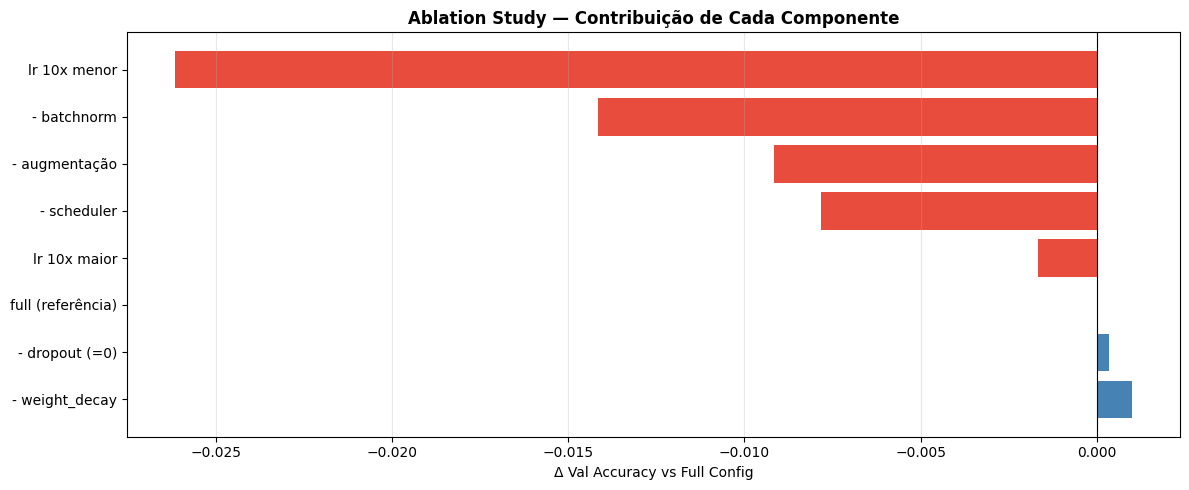

Barras vermelhas à esquerda = remover esse componente PIORA o modelo.
Quanto mais à esquerda, mais IMPORTANTE é aquele componente.


In [ ]:
# Visualizar ablação
fig, ax = plt.subplots(figsize=(12, 5))

names_abl = list(ablation_results.keys())
accs_abl = list(ablation_results.values())
deltas = [a - ref_acc for a in accs_abl]

# Ordenar por impacto
order = np.argsort(deltas)[::-1]
names_sorted = [names_abl[i] for i in order]
deltas_sorted = [deltas[i] for i in order]
colors_abl = ['steelblue' if d >= 0 else '#e74c3c' for d in deltas_sorted]

ax.barh(range(len(names_sorted)), deltas_sorted, color=colors_abl)
ax.set_yticks(range(len(names_sorted)))
ax.set_yticklabels(names_sorted)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Δ Val Accuracy vs Full Config')
ax.set_title('Ablation Study — Contribuição de Cada Componente', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Barras vermelhas à esquerda = remover esse componente PIORA o modelo.')
print('Quanto mais à esquerda, mais IMPORTANTE é aquele componente.')

---
## Fase 7: Learning Rate Finder & Scheduler Tuning

### Experimento: LR Range Test

O **LR Finder** (Leslie Smith, 2017) varre learning rates exponencialmente
e plota a loss. O LR ideal fica no ponto onde a loss cai mais rápido.

Rodando LR Finder...


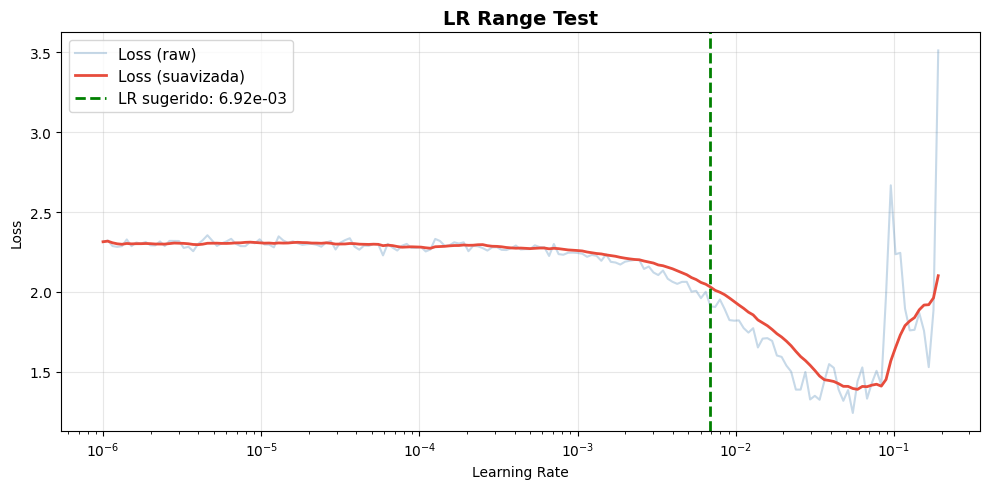


💡 LR sugerido: 6.92e-03
   Regra prática: use um LR ~10x menor que o ponto mínimo da curva.


In [ ]:
def lr_finder(config, lr_min=1e-6, lr_max=1.0, num_steps=200):
    """LR Range Test: varre LRs e plota loss."""
    set_seed(42)
    model = build_model(config)
    optimizer = optim.SGD(model.parameters(), lr=lr_min)
    train_loader, _ = create_dataloaders(config)

    lr_mult = (lr_max / lr_min) ** (1 / num_steps)
    lrs, losses_lr = [], []
    best_loss_lr = float('inf')
    batch_iter = iter(train_loader)

    model.train()
    for step in range(num_steps):
        try:
            imgs, labels = next(batch_iter)
        except StopIteration:
            batch_iter = iter(train_loader)
            imgs, labels = next(batch_iter)

        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = F.cross_entropy(logits, labels)

        # Parar se a loss explodir
        if step > 10 and loss.item() > best_loss_lr * 4:
            break
        if loss.item() < best_loss_lr:
            best_loss_lr = loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        current_lr = optimizer.param_groups[0]['lr']
        lrs.append(current_lr)
        losses_lr.append(loss.item())

        # Aumentar LR
        for pg in optimizer.param_groups:
            pg['lr'] *= lr_mult

    return lrs, losses_lr

print('Rodando LR Finder...')
lrs_found, losses_found = lr_finder(BASE_CONFIG)

# Suavizar
window = 10
smoothed_losses = [np.mean(losses_found[max(0,i-window):i+1]) for i in range(len(losses_found))]

# Encontrar LR ótimo (ponto de maior derivada negativa)
gradients = np.gradient(smoothed_losses)
min_grad_idx = np.argmin(gradients[:len(gradients)*3//4])  # ignorar parte instável
suggested_lr = lrs_found[min_grad_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lrs_found, losses_found, alpha=0.3, color='steelblue', label='Loss (raw)')
ax.plot(lrs_found[:len(smoothed_losses)], smoothed_losses, color='#e74c3c', linewidth=2, label='Loss (suavizada)')
ax.axvline(x=suggested_lr, color='green', linestyle='--', linewidth=2, label=f'LR sugerido: {suggested_lr:.2e}')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Loss')
ax.set_title('LR Range Test', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n💡 LR sugerido: {suggested_lr:.2e}')
print(f'   Regra prática: use um LR ~10x menor que o ponto mínimo da curva.')

---
## Fase 8: Monitoramento Profundo — Gradientes, Ativações, Pesos

### Experimento: Diagnóstico Camada por Camada

Este é o tipo de monitoramento que separa **debug amador** de **debug profissional**.
O W&B loga histogramas automaticamente com `wandb.watch()`, mas vamos também
construir diagnósticos customizados.

Treinamento com monitoramento profundo (log_gradients=True)...
(Verifique no W&B: aba "System", "Gradients", "Parameters")



  Epoch  1/15 | train: 0.5800 / 0.786 | val: 0.3614 / 0.869 | gap: -0.083 | lr: 9.89e-04 | 21.7s ★
  Epoch  2/15 | train: 0.3749 / 0.862 | val: 0.3666 / 0.869 | gap: -0.007 | lr: 9.57e-04 | 22.6s
  Epoch  3/15 | train: 0.3220 / 0.883 | val: 0.2903 / 0.896 | gap: -0.014 | lr: 9.05e-04 | 25.2s ★
  Epoch  4/15 | train: 0.2956 / 0.891 | val: 0.2724 / 0.902 | gap: -0.011 | lr: 8.35e-04 | 21.0s ★
  Epoch  5/15 | train: 0.2745 / 0.901 | val: 0.2363 / 0.910 | gap: -0.009 | lr: 7.50e-04 | 23.1s ★
  Epoch  6/15 | train: 0.2537 / 0.907 | val: 0.2491 / 0.910 | gap: -0.003 | lr: 6.55e-04 | 23.0s
  Epoch  7/15 | train: 0.2445 / 0.911 | val: 0.2150 / 0.921 | gap: -0.010 | lr: 5.52e-04 | 23.3s ★
  Epoch  8/15 | train: 0.2275 / 0.917 | val: 0.2152 / 0.922 | gap: -0.005 | lr: 4.48e-04 | 24.1s
  Epoch  9/15 | train: 0.2160 / 0.921 | val: 0.2067 / 0.925 | gap: -0.004 | lr: 3.45e-04 | 22.0s ★
  Epoch 10/15 | train: 0.2024 / 0.927 | val: 0.1970 / 0.928 | gap: -0.001 | lr: 2.50e-04 | 24.0s ★
  Epoch 11/15 | 

batch/grad_norm,▅▄▆██▇▄▅▄▄▄▄▂▃▃▅▅▃▂▁▂▂▂▃▃▄▂▃▄▂▅▆▁▅▆▄▂▄▃▃
batch/train_loss,█▂▃▂▂▂▂▁▁▂▁▁▁▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▂▄█▁▅▄▅▆▃▆▅▃▆▃▅
generalization_gap,▁▇▇▇▇█▇▇██▇████
grad_norm/max,▆█▃▂▁▂▂▃▂▃▁▆▅▃▄
grad_norm/mean,█▅▄▂▁▁▁▁▁▁▁▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▄▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


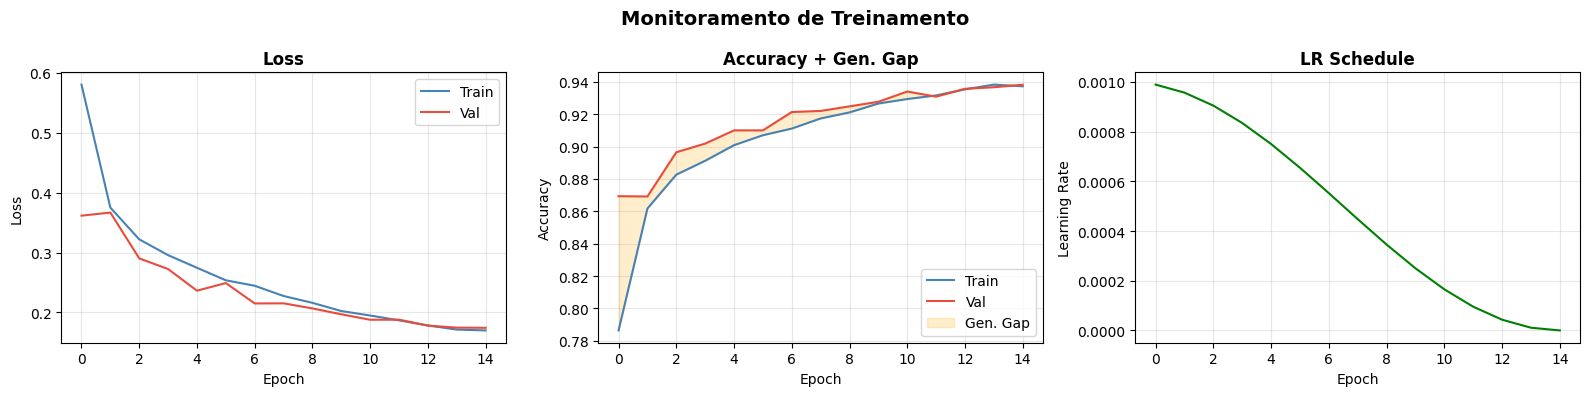

In [ ]:
# Treinar o melhor modelo logando TUDO
print('Treinamento com monitoramento profundo (log_gradients=True)...')
print('(Verifique no W&B: aba "System", "Gradients", "Parameters")\n')

monitored_result = train_experiment(
    config=best_config,
    run_name='monitored_deep_logging',
    tags=['monitoring', 'phase8'],
    log_gradients=True,
)

# Plotar evolução de train/val
h = monitored_result['history']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(h['train_loss'], label='Train', color='steelblue')
axes[0].plot(h['val_loss'], label='Val', color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(h['train_acc'], label='Train', color='steelblue')
axes[1].plot(h['val_acc'], label='Val', color='#e74c3c')
axes[1].fill_between(range(len(h['train_acc'])),
                      h['val_acc'], h['train_acc'],
                      alpha=0.2, color='orange', label='Gen. Gap')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy + Gen. Gap', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR
axes[2].plot(h['lr'], color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Monitoramento de Treinamento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Fase 9: Receita de Depuração — "O Modelo Não Aprende!"

### Checklist de Depuração (em ordem)

```
1. 🔍 DADOS
   □ As labels estão corretas? (Visualize amostras + labels)
   □ A normalização está correta? (mean≈0, std≈1 do input)
   □ O dataloader embaralha? (shuffle=True no train)
   □ Há classes desbalanceadas? (contar por classe)
   □ Os dados estão no dtype correto? (float32 para imagens)

2. 📐 MODELO
   □ Loss inicial = -log(1/num_classes)? Se não, bug no modelo ou loss
   □ Overfit em 1 batch? Se não, bug grave
   □ Shapes corretas? (printar shapes intermediárias)
   □ Pesos inicializados? (não todos zero, não NaN)

3. 📈 OTIMIZAÇÃO
   □ LR adequado? (testar com LR Finder)
   □ Gradientes fluindo? (verificar normas, zeros)
   □ Grad norm explodindo? (adicionar gradient clipping)
   □ Loss = NaN? (LR muito alto, input com NaN, log(0))

4. 🏗️ TREINAMENTO
   □ model.train() no treino, model.eval() na validação?
   □ optimizer.zero_grad() antes de loss.backward()?
   □ Scheduler correto? (step por epoch vs por batch)
   □ BatchNorm/Dropout se comportando diferente em train vs eval?

5. 🔄 OVERFITTING
   □ Train loss cai, val loss sobe? → regularização (dropout, weight_decay, augmentação)
   □ Ambos estagnados? → modelo muito pequeno ou LR muito baixo
   □ Ambos altos? → problema nos dados ou no pipeline
```

### Demonstração: Diagnosticando Problemas Comuns

🚨 Demo: Treinando com LR = 100 (muito alto)



  Epoch  1/5 | train: 67253352.0645 / 0.103 | val: 34.8555 / 0.100 | gap: 0.003 | lr: 1.00e+02 | 19.8s ★
  Epoch  2/5 | train: 49.8919 / 0.098 | val: 49.0367 / 0.100 | gap: -0.002 | lr: 1.00e+02 | 19.7s
  Epoch  3/5 | train: 52.5091 / 0.099 | val: 25.4302 / 0.100 | gap: -0.001 | lr: 1.00e+02 | 19.2s ★
  Epoch  4/5 | train: 54.0108 / 0.101 | val: 39.6075 / 0.100 | gap: 0.001 | lr: 1.00e+02 | 21.3s
  Epoch  5/5 | train: 49.0127 / 0.101 | val: 64.7520 / 0.100 | gap: 0.001 | lr: 1.00e+02 | 20.1s


batch/grad_norm,█▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂
batch/train_loss,▁▄▅▇▅▄█▅▅▅▅▆▃▅▄▃▆▆▆▆▄▆▃▃▄
epoch,▁▃▅▆█
epoch_time_s,▃▂▁█▄
generalization_gap,█▁▂▅▅
grad_norm/max,█▁▁▁▁
grad_norm/mean,█▁▁▁▁
lr,▁▁▁▁▁
train/accuracy,█▁▂▅▅
train/loss,█▁▁▁▁
+10,...



🚨 Demo: Treinando com LR = 1e-8 (muito baixo)



  Epoch  1/5 | train: 2.2983 / 0.130 | val: 2.2774 / 0.171 | gap: -0.040 | lr: 1.00e-08 | 19.3s ★
  Epoch  2/5 | train: 2.2940 / 0.134 | val: 2.2744 / 0.174 | gap: -0.040 | lr: 1.00e-08 | 20.6s ★
  Epoch  3/5 | train: 2.2929 / 0.135 | val: 2.2714 / 0.177 | gap: -0.042 | lr: 1.00e-08 | 19.0s ★
  Epoch  4/5 | train: 2.2890 / 0.140 | val: 2.2685 / 0.181 | gap: -0.042 | lr: 1.00e-08 | 19.5s ★
  Epoch  5/5 | train: 2.2848 / 0.140 | val: 2.2654 / 0.186 | gap: -0.046 | lr: 1.00e-08 | 20.8s ★


batch/grad_norm,▃▃▅▁▄█▆▁▃▄▂▅▃▅▂▅▄▄▃▆▆▄▂▆▅
batch/train_loss,▆▅▅▂▁▆▆▃▁▄▅█▄▅▁▄▄▄▆█▆▅▃▄▅
epoch,▁▃▅▆█
epoch_time_s,▂▇▁▃█
generalization_gap,▇█▆▅▁
grad_norm/max,▅▅█▁▇
grad_norm/mean,▇█▅▁▂
lr,▁▁▁▁▁
train/accuracy,▁▄▄▇█
train/loss,█▆▅▃▁
+10,...


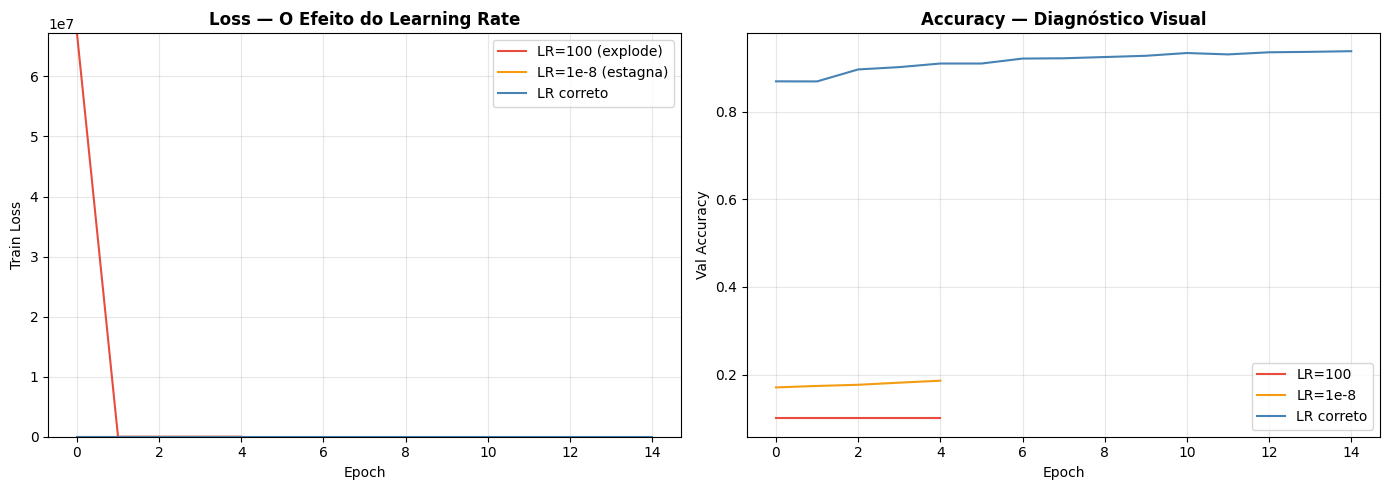


Diagnóstico:
   LR muito alto → loss oscila/explode, accuracy = ~10% (aleatório)
   LR muito baixo → loss quase não se move, accuracy sobe devagar
   LR correto → loss cai suavemente, accuracy sobe consistentemente


In [ ]:
# === DEMO: Modelo que "não aprende" por LR errado ===
print('🚨 Demo: Treinando com LR = 100 (muito alto)\n')
broken_config_1 = {**BASE_CONFIG, 'lr': 100, 'scheduler': None, 'epochs': 5}
r1 = train_experiment(broken_config_1, run_name='debug_lr_too_high',
                      tags=['debug', 'phase9'])

print(f'\n🚨 Demo: Treinando com LR = 1e-8 (muito baixo)\n')
broken_config_2 = {**BASE_CONFIG, 'lr': 1e-8, 'scheduler': None, 'epochs': 5}
r2 = train_experiment(broken_config_2, run_name='debug_lr_too_low',
                      tags=['debug', 'phase9'])

# Plotar comparação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(r1['history']['train_loss'], label='LR=100 (explode)', color='#e74c3c')
ax1.plot(r2['history']['train_loss'], label='LR=1e-8 (estagna)', color='#f39c12')
ax1.plot(monitored_result['history']['train_loss'], label='LR correto', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.set_title('Loss — O Efeito do Learning Rate', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(5, max(r1['history']['train_loss'][:3])))

ax2.plot(r1['history']['val_acc'], label='LR=100', color='#e74c3c')
ax2.plot(r2['history']['val_acc'], label='LR=1e-8', color='#f39c12')
ax2.plot(monitored_result['history']['val_acc'], label='LR correto', color='steelblue')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Val Accuracy')
ax2.set_title('Accuracy — Diagnóstico Visual', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDiagnóstico:')
print('   LR muito alto → loss oscila/explode, accuracy = ~10% (aleatório)')
print('   LR muito baixo → loss quase não se move, accuracy sobe devagar')
print('   LR correto → loss cai suavemente, accuracy sobe consistentemente')

---
## Fase 10: Seleção Final com Justificativa Técnica

### O momento de tocar o Test Set (UMA VEZ)

Até agora, **nunca** vimos métricas no test set.
A seleção do modelo foi baseada 100% na validação.
Agora avaliamos o modelo final no test set para reportar o resultado verdadeiro.

In [ ]:
# === SELEÇÃO FINAL ===
print('SELEÇÃO DO MODELO FINAL\n')

# Justificativa
best_name = top_names[0]
best_mean = np.mean(multi_seed_results[best_name])
best_std = np.std(multi_seed_results[best_name])

print(f'Modelo selecionado: {best_name}')
print(f'Val accuracy: {best_mean:.4f} ± {best_std:.4f} (5 seeds)')
print(f'\nJustificativa:')
print(f'  1. Melhor val accuracy média entre {len(top_names)} candidatos finais')
print(f'  2. Diferença estatisticamente significativa (p < 0.05)')
print(f'  3. Ablation confirmou contribuição de cada componente')

# Retreinar com a melhor seed para ter o modelo final
best_seed_idx = np.argmax(multi_seed_results[best_name])
best_seed = SEEDS[best_seed_idx]
print(f'  4. Seed com melhor val: {best_seed}')

if best_name == 'baseline':
    final_config = {**BASE_CONFIG, 'seed': best_seed}
else:
    final_config = {**CANDIDATES[best_name], 'seed': best_seed}

print(f'\nRetreinando modelo final...')
final_result = train_experiment(
    config=final_config,
    run_name='FINAL_MODEL',
    tags=['final', 'phase10'],
    log_gradients=True,
)

SELEÇÃO DO MODELO FINAL

Modelo selecionado: deeper_gelu_highdrop
Val accuracy: 0.9344 ± 0.0019 (5 seeds)

Justificativa:
  1. Melhor val accuracy média entre 3 candidatos finais
  2. Diferença estatisticamente significativa (p < 0.05)
  3. Ablation confirmou contribuição de cada componente
  4. Seed com melhor val: 42

Retreinando modelo final...


  Epoch  1/15 | train: 0.5800 / 0.786 | val: 0.3614 / 0.869 | gap: -0.083 | lr: 9.89e-04 | 22.5s ★
  Epoch  2/15 | train: 0.3749 / 0.862 | val: 0.3666 / 0.869 | gap: -0.007 | lr: 9.57e-04 | 20.7s
  Epoch  3/15 | train: 0.3220 / 0.883 | val: 0.2903 / 0.896 | gap: -0.014 | lr: 9.05e-04 | 22.7s ★
  Epoch  4/15 | train: 0.2956 / 0.891 | val: 0.2724 / 0.902 | gap: -0.011 | lr: 8.35e-04 | 22.6s ★
  Epoch  5/15 | train: 0.2745 / 0.901 | val: 0.2363 / 0.910 | gap: -0.009 | lr: 7.50e-04 | 23.4s ★
  Epoch  6/15 | train: 0.2537 / 0.907 | val: 0.2491 / 0.910 | gap: -0.003 | lr: 6.55e-04 | 24.7s
  Epoch  7/15 | train: 0.2445 / 0.911 | val: 0.2150 / 0.921 | gap: -0.010 | lr: 5.52e-04 | 22.2s ★
  Epoch  8/15 | train: 0.2275 / 0.917 | val: 0.2152 / 0.922 | gap: -0.005 | lr: 4.48e-04 | 23.6s
  Epoch  9/15 | train: 0.2160 / 0.921 | val: 0.2067 / 0.925 | gap: -0.004 | lr: 3.45e-04 | 21.5s ★
  Epoch 10/15 | train: 0.2024 / 0.927 | val: 0.1970 / 0.928 | gap: -0.001 | lr: 2.50e-04 | 23.2s ★
  Epoch 11/15 | 

batch/grad_norm,▅▄▇▇▄▄▇▄█▅▆▅▂▂▃▃▅▃▄▂▂▂▂▃▃▃▂▃▃▂▅▃▅▁▆▄▅▄▃▃
batch/train_loss,█▂▃▂▂▁▂▂▂▁▁▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time_s,▄▁▄▄▆█▄▆▂▅▆▄▆▃▇
generalization_gap,▁▇▇▇▇█▇▇██▇████
grad_norm/max,▆█▃▂▁▂▂▃▂▃▁▆▅▃▄
grad_norm/mean,█▅▄▂▁▁▁▁▁▁▁▂▂▂▂
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇█████
train/loss,█▄▄▃▃▂▂▂▂▂▁▁▁▁▁
+18,...


AVALIAÇÃO FINAL NO TEST SET

Este é o ÚNICO momento em que tocamos o test set!

  Test Loss:     0.1984
  Test Accuracy: 0.9291
  Val Accuracy:  0.9382
  Gap test-val:  0.0091

Classification Report:

              precision    recall  f1-score   support

     T-shirt       0.88      0.88      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.91      0.90      1000
       Dress       0.94      0.93      0.93      1000
        Coat       0.90      0.90      0.90      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.80      0.77      0.79      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



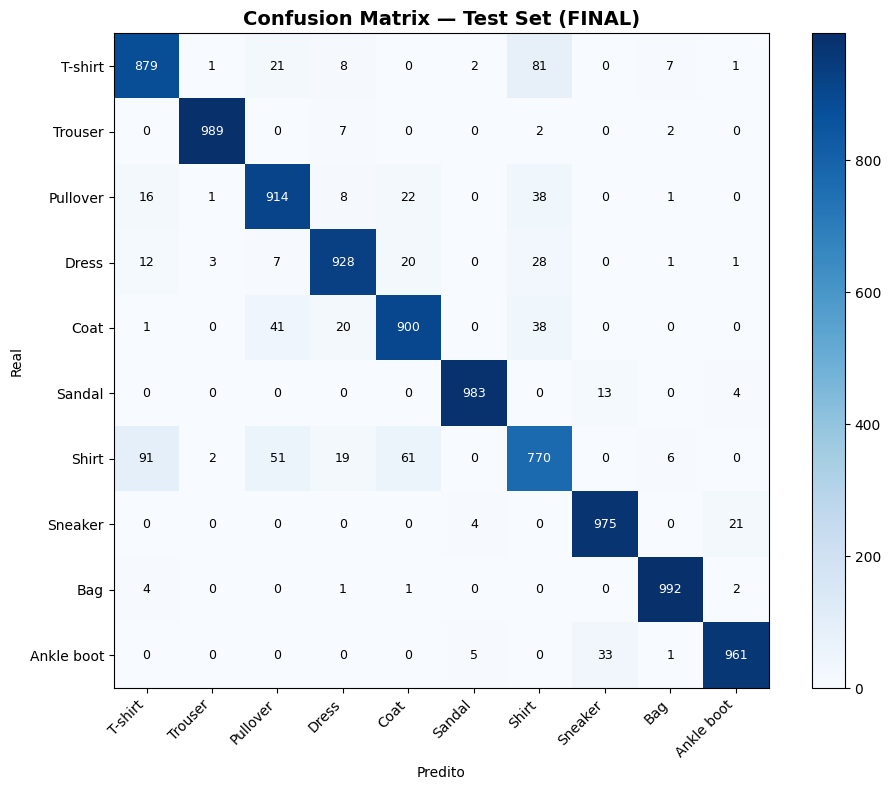


Pares mais confusos (top 5):
   Shirt        → T-shirt     : 91 erros
   T-shirt      → Shirt       : 81 erros
   Shirt        → Coat        : 61 erros
   Shirt        → Pullover    : 51 erros
   Coat         → Pullover    : 41 erros


In [ ]:
# === AVALIAÇÃO NO TEST SET (ÚNICA VEZ!) ===
print('AVALIAÇÃO FINAL NO TEST SET\n')
print('Este é o ÚNICO momento em que tocamos o test set!\n')

# Carregar melhor modelo
final_model = build_model(final_config)
final_model.load_state_dict(final_result['model_state'])

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)
test_metrics = evaluate(final_model, test_loader)

print(f'  Test Loss:     {test_metrics["loss"]:.4f}')
print(f'  Test Accuracy: {test_metrics["accuracy"]:.4f}')
print(f'  Val Accuracy:  {final_result["best_val_acc"]:.4f}')
print(f'  Gap test-val:  {abs(test_metrics["accuracy"] - final_result["best_val_acc"]):.4f}')

# Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

print(f'\nClassification Report:\n')
print(classification_report(test_metrics['labels'], test_metrics['preds'],
                            target_names=CLASS_NAMES))

# Plotar confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Confusion Matrix — Test Set (FINAL)', fontsize=14, fontweight='bold')

# Anotar valores
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.show()

# Análise de erros
print('\nPares mais confusos (top 5):')
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
for _ in range(5):
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f'   {CLASS_NAMES[idx[0]]:12s} → {CLASS_NAMES[idx[1]]:12s}: {cm_no_diag[idx[0], idx[1]]} erros')
    cm_no_diag[idx[0], idx[1]] = 0

---
## Fase 11: Export de Artefatos e Checklist de Produção

### O que salvar e versionar:

```
artifacts/
├── model.pt              ← Pesos do modelo
├── model_full.pt         ← Modelo completo (arquitetura + pesos)
├── model_scripted.pt     ← TorchScript (para deploy sem Python)
├── config.json           ← Configuração completa
├── metrics.json          ← Métricas finais
├── normalization.json    ← Estatísticas de normalização (mean, std)
└── training_report.json  ← Relatório completo do experimento
```

In [ ]:
import json

os.makedirs('artifacts', exist_ok=True)

# 1. Salvar pesos
torch.save(final_result['model_state'], 'artifacts/model.pt')
print('✅ artifacts/model.pt (pesos)')

# 2. Salvar modelo completo
torch.save({
    'model_state_dict': final_result['model_state'],
    'config': final_config,
    'class_names': CLASS_NAMES,
    'normalization': {'mean': train_mean, 'std': train_std},
}, 'artifacts/model_full.pt')
print('✅ artifacts/model_full.pt (modelo + config + normalization)')

# 3. TorchScript (para deploy)
final_model.eval()
try:
    scripted = torch.jit.script(final_model)
    scripted.save('artifacts/model_scripted.pt')
    print('✅ artifacts/model_scripted.pt (TorchScript)')
except Exception as e:
    # Fallback: tracing
    traced = torch.jit.trace(final_model, torch.randn(1, 1, 28, 28).to(device))
    traced.save('artifacts/model_traced.pt')
    print('✅ artifacts/model_traced.pt (TorchScript via tracing)')

# 4. Config
config_serializable = {k: str(v) if not isinstance(v, (int, float, str, bool, list)) else v
                       for k, v in final_config.items()}
with open('artifacts/config.json', 'w') as f:
    json.dump(config_serializable, f, indent=2)
print('✅ artifacts/config.json')

# 5. Métricas
metrics = {
    'test_accuracy': test_metrics['accuracy'],
    'test_loss': test_metrics['loss'],
    'val_accuracy': final_result['best_val_acc'],
    'val_loss': final_result['best_val_loss'],
    'val_accuracy_multi_seed_mean': float(best_mean),
    'val_accuracy_multi_seed_std': float(best_std),
    'training_time_s': final_result['total_time'],
    'stopped_epoch': final_result['stopped_epoch'],
}
with open('artifacts/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('✅ artifacts/metrics.json')

# 6. Normalização (crucial para inferência!)
with open('artifacts/normalization.json', 'w') as f:
    json.dump({'mean': train_mean, 'std': train_std}, f)
print('✅ artifacts/normalization.json')

# 7. Upload para W&B como artefato versionado
try:
    run = wandb.init(project=PROJECT_NAME, name='artifact_upload',
                     tags=['artifacts'], mode=WANDB_MODE, reinit=True)
    artifact = wandb.Artifact('fashion-mnist-model', type='model',
                               description=f'Final model: {best_name}, test_acc={test_metrics["accuracy"]:.4f}')
    artifact.add_dir('artifacts')
    run.log_artifact(artifact)
    wandb.finish()
    print('\n✅ Artefatos uploadeados para W&B!')
except:
    print('\n⚠️ Upload W&B falhou (modo offline?). Artefatos salvos localmente.')

print(f'\n📁 Conteúdo de artifacts/:')
for f in sorted(os.listdir('artifacts')):
    size = os.path.getsize(f'artifacts/{f}')
    print(f'   {f:30s} {size/1024:.1f} KB')

✅ artifacts/model.pt (pesos)
✅ artifacts/model_full.pt (modelo + config + normalization)
✅ artifacts/model_scripted.pt (TorchScript)
✅ artifacts/config.json
✅ artifacts/metrics.json
✅ artifacts/normalization.json


wandb: Adding directory to artifact (artifacts)... Done. 0.0s



✅ Artefatos uploadeados para W&B!

📁 Conteúdo de artifacts/:
   config.json                    0.4 KB
   metrics.json                   0.3 KB
   model.pt                       1277.7 KB
   model_full.pt                  1281.1 KB
   model_scripted.pt              1310.7 KB
   normalization.json             0.1 KB


Demo: Carregando modelo exportado para inferência



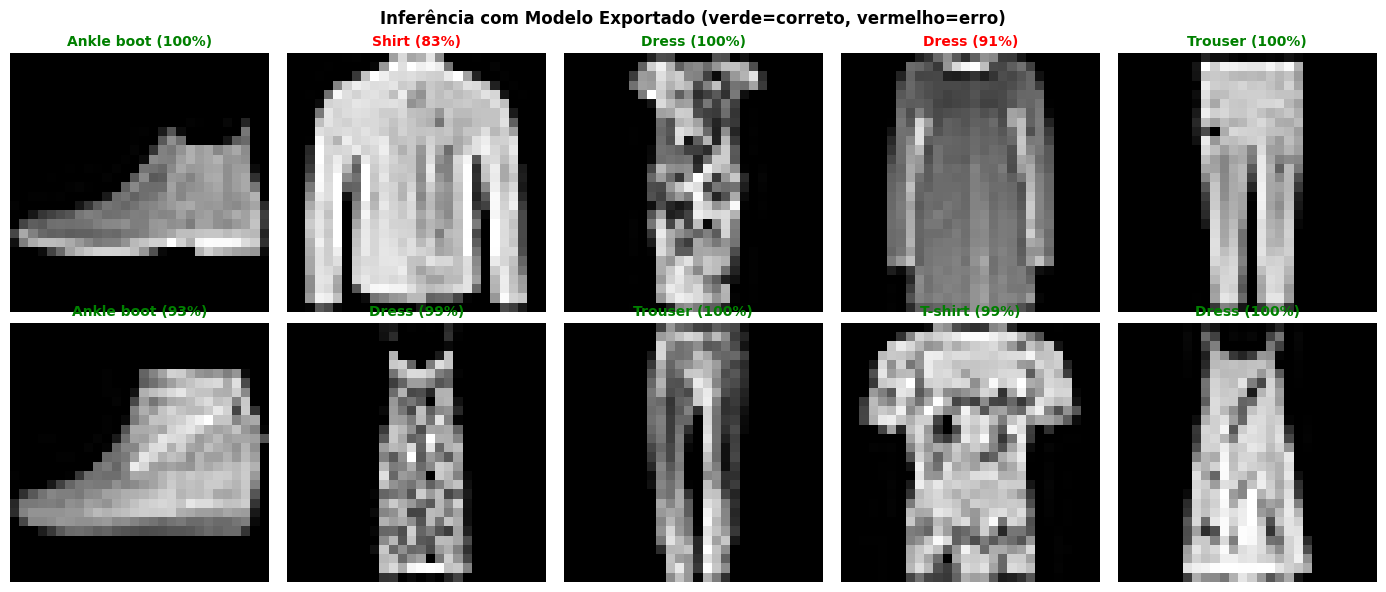

In [ ]:
# === DEMO: Carregando modelo exportado para inferência ===
print('Demo: Carregando modelo exportado para inferência\n')

# Simular um novo ambiente
checkpoint = torch.load('artifacts/model_full.pt', map_location='cpu')
loaded_model = build_model(checkpoint['config'])
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

norm_stats = checkpoint['normalization']
inference_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((norm_stats['mean'],), (norm_stats['std'],)),
])

# Predizer algumas imagens do test set
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img_raw, true_label = raw_test[i * 50]
    img_tensor = inference_transform(img_raw).unsqueeze(0).to(device) # Move tensor to the same device as the model

    with torch.no_grad():
        logits = loaded_model(img_tensor)
        probs = F.softmax(logits, dim=1)
        pred = probs.argmax(1).item()
        conf = probs[0, pred].item()

    correct = pred == true_label
    color = 'green' if correct else 'red'
    ax.imshow(img_raw, cmap='gray')
    ax.set_title(f'{CLASS_NAMES[pred]} ({conf:.0%})', color=color, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Inferência com Modelo Exportado (verde=correto, vermelho=erro)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Checklist de Produção

Antes de colocar o modelo em produção, verifique cada item:

### Dados
- [ ] Normalização usa stats do **train** (salvas em `normalization.json`)
- [ ] Pipeline de inferência é idêntico ao `eval_transform`
- [ ] Sem data augmentation na inferência
- [ ] Input validation (shape, dtype, range esperado)

### Modelo
- [ ] `model.eval()` chamado antes de inferência
- [ ] `torch.no_grad()` no contexto de inferência
- [ ] Exportado em formato adequado (TorchScript, ONNX, etc.)
- [ ] Testado no device de produção (CPU vs GPU)
- [ ] Tamanho do modelo aceitável para o ambiente

### Qualidade
- [ ] Métricas no test set reportadas honestamente
- [ ] Confusion matrix analisada (quais erros são aceitáveis?)
- [ ] Resultados reprodutíveis com a seed registrada
- [ ] Multi-seed mostra resultado estável (baixo std)
- [ ] Ablation confirma que cada componente contribui

### Rastreabilidade
- [ ] Código versionado (git commit hash)
- [ ] Config completa salva e versionada
- [ ] Dataset versionado (hash ou versão)
- [ ] Runs logados no W&B (ou equivalente)
- [ ] Artefatos versionados e armazenados

### Monitoramento em Produção
- [ ] Logging de predições (para detectar data drift)
- [ ] Alertas se accuracy cair abaixo de threshold
- [ ] Pipeline de re-treinamento documentado
- [ ] Fallback definido (o que acontece se o modelo falhar?)

---
## 📊 Resumo do W&B

### O que ver no dashboard do W&B:

| Seção | O que procurar |
|-------|----------------|
| **Charts** | Curvas de loss/accuracy (train vs val), generalization gap |
| **System** | Uso de GPU/CPU/RAM durante o treinamento |
| **Gradients** | Histogramas — buscar vanishing (concentrado em 0) ou exploding |
| **Parameters** | Distribuição dos pesos — devem evoluir, não ficar estáticos |
| **Tables** | Confusion matrices, predições |
| **Runs** | Comparar runs lado a lado (seleção de métricas, filtros por tag) |
| **Artifacts** | Modelos versionados com metadata |

### Dica de ouro:
No W&B, use **tags** para organizar seus experimentos:
- `baseline`, `candidate`, `multi-seed`, `ablation`, `debug`, `final`
- Depois filtre por tag para comparar apenas o que interessa

### O que aprendemos:

> **Treinar um modelo é 20% do trabalho. Os outros 80% são:**
> protocolo de dados, sanity checks, comparação rigorosa,
> ablation, depuração, e preparação para produção.
> **Sem rastreabilidade, não existe ciência — existe tentativa e erro.**